# Build a sentiment classifier that can predict whether an IMDb movie review is positive or negative.



### Load & Explore Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("Imdb.xlsx")  # Place your file in the same directory

# Basic info
print(df.info())
print(df.head())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


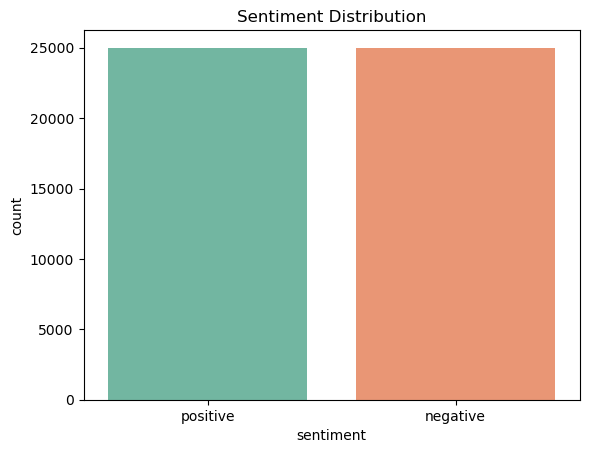

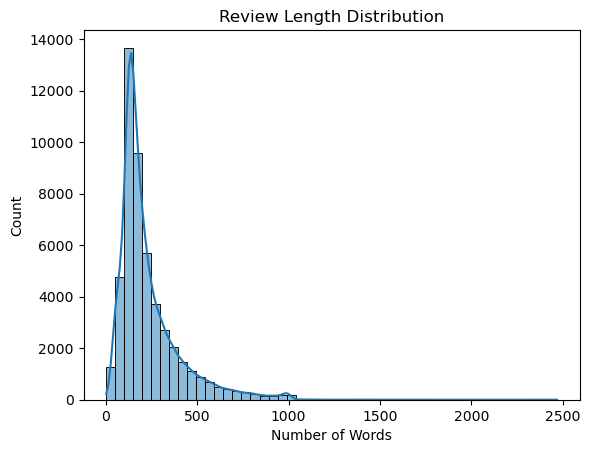

In [2]:
# Check class balance
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='Set2', legend=False)
plt.title("Sentiment Distribution")
plt.show()

# Add review length column
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

# Review length distribution
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.show()

 ### Import & Download NLTK Resources

In [3]:
!pip install nltk scikit-learn
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mukulsinghlatwal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mukulsinghlatwal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mukulsinghlatwal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Define Preprocessing Function

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove punctuation/special chars/numbers
    text = text.lower()  # Lowercase
    tokens = word_tokenize(text)  # Tokenization
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]  # Stopwords removal
    tokens = [lemmatizer.lemmatize(stemmer.stem(word)) for word in tokens]  # Stemming + Lemmatization
    return ' '.join(tokens)


### Apply to the Dataset

In [5]:
df['cleaned_review'] = df['review'].apply(preprocess)


### Vectorization (BoW and TF-IDF)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['cleaned_review']).toarray()


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review']).toarray()


In [8]:
# Word count
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Character count
df['char_count'] = df['review'].apply(len)

# Average word length
df['avg_word_length'] = df['char_count'] / df['word_count']


### Model Training & Evaluation (Logistic, Naive Bayes, SVM, Random Forest)

In [9]:
from sklearn.model_selection import train_test_split

# Convert labels to binary
X = X_tfidf
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n {name} Results:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



 Logistic Regression Results:
Accuracy : 0.8863
Precision: 0.8766409266409266
Recall   : 0.9011708672355626
F1 Score : 0.8887366669928565

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



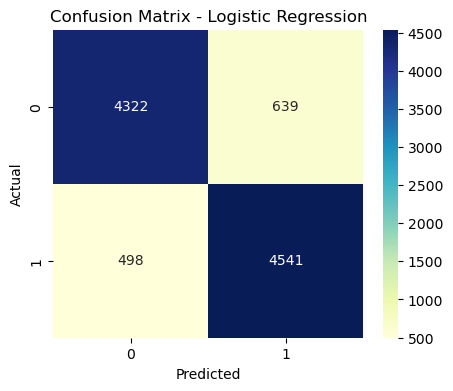

In [12]:
evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000))


 Naive Bayes Results:
Accuracy : 0.8499
Precision: 0.8464551508029768
Recall   : 0.8577098630680691
F1 Score : 0.8520453425332676

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



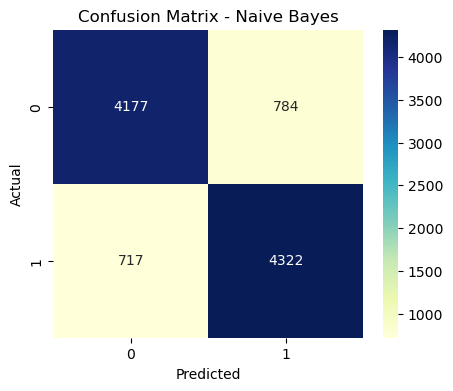

In [13]:
evaluate_model("Naive Bayes", MultinomialNB())


 Random Forest Results:
Accuracy : 0.8471
Precision: 0.8564175467099919
Recall   : 0.836872395316531
F1 Score : 0.846532169025394

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



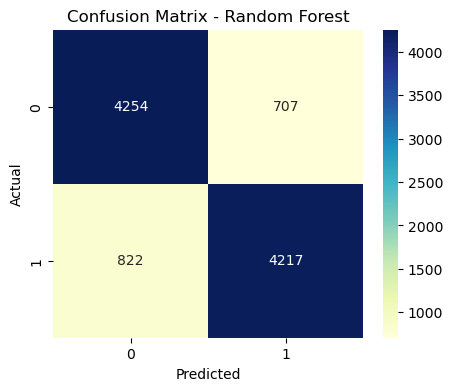

In [14]:
evaluate_model("Random Forest", RandomForestClassifier())

### Logistic Regression Outperformed Other Models
### Achieved the highest accuracy (88.63%), precision, recall, and F1 score.

### Works best with TF-IDF features, which are linearly separable.



### Final Recommendation
### Use Logistic Regression with TF-IDF for production-level IMDb review sentiment prediction.

### It’s accurate, fast, and scalable.

